# Data Preprocessing

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

## Load Data


In [2]:
movies  = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')

print('Movies shape :', movies.shape)
print('Ratings shape:', ratings.shape)
print()
print(movies.head(3))
print()
print(ratings.head(3))

Movies shape : (9742, 3)
Ratings shape: (100836, 4)

   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224


## Check Missing Values


In [3]:
print('Missing values in movies = ' , movies.isnull().sum().sum() )
print('Missing values in ratings = ' , ratings.isnull().sum().sum() )
print('\nduplicated values in movies = ' , movies.duplicated().sum())
print('duplicated values in ratings = ' , ratings.duplicated().sum())

Missing values in movies =  0
Missing values in ratings =  0

duplicated values in movies =  0
duplicated values in ratings =  0


In [4]:
movies['genres'] = movies['genres'].fillna('Unknown')
movies['genres'] = movies['genres'].replace('(no genres listed)', 'Unknown')

# Create space-separate for TF-IDF
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)

movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

before = len(ratings)
ratings = ratings.drop_duplicates(subset=['userId', 'movieId'])
print(f'Duplicate ratings removed: {before - len(ratings)}')
print(f'Ratings before: {before:,}  |  after: {len(ratings):,}')

ratings = ratings.drop(columns=['timestamp'])
print('timestamp column dropped')

print(f'\nTotal users  : {ratings["userId"].nunique()}')
print(f'Total movies : {ratings["movieId"].nunique()}')
print(f'Rating range : {ratings["rating"].min()} – {ratings["rating"].max()}')

Duplicate ratings removed: 0
Ratings before: 100,836  |  after: 100,836
timestamp column dropped

Total users  : 610
Total movies : 9724
Rating range : 0.5 – 5.0


## Exploratory Data Analysis (EDA)

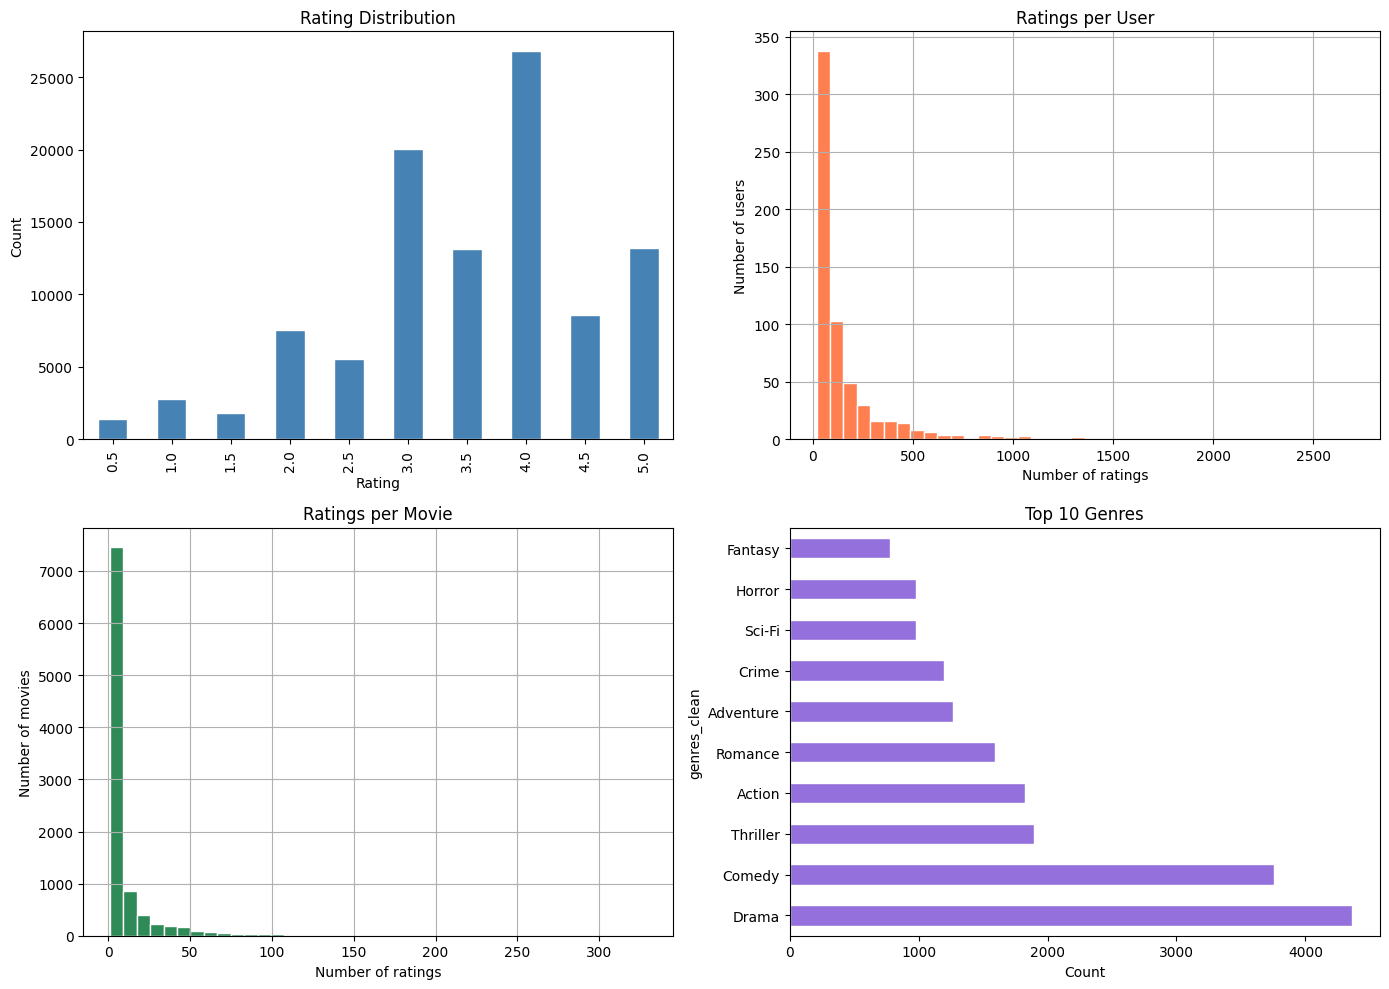

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0][0], color='steelblue', edgecolor='white')
axes[0][0].set_title('Rating Distribution')
axes[0][0].set_xlabel('Rating')
axes[0][0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ratings.groupby('userId').size()
ratings_per_user.hist(bins=40, ax=axes[0][1], color='coral', edgecolor='white')
axes[0][1].set_title('Ratings per User')
axes[0][1].set_xlabel('Number of ratings')
axes[0][1].set_ylabel('Number of users')

# Ratings per movie
ratings_per_movie = ratings.groupby('movieId').size()
ratings_per_movie.hist(bins=40, ax=axes[1][0], color='seagreen', edgecolor='white')
axes[1][0].set_title('Ratings per Movie')
axes[1][0].set_xlabel('Number of ratings')
axes[1][0].set_ylabel('Number of movies')

# Top 10 genres
movies['genres_clean'].str.split().explode().value_counts().head(10).plot(
    kind='barh', ax=axes[1][1], color='mediumpurple', edgecolor='white')
axes[1][1].set_title('Top 10 Genres')
axes[1][1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [6]:
print('Cold-Start Analysis ')

ratings_per_user  = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

cold_users = (ratings_per_user < 5).sum()
print(f'Users with < 5 ratings  : {cold_users} ({cold_users / len(ratings_per_user) * 100:.1f}%)')

# Movies with fewer than 5 ratings
cold_movies = (ratings_per_movie < 5).sum()
print(f'Movies with < 5 ratings : {cold_movies} ({cold_movies / len(ratings_per_movie) * 100:.1f}%)')

print(f'\nMedian ratings per user  : {ratings_per_user.median():.0f}')
print(f'Median ratings per movie : {ratings_per_movie.median():.0f}')
print(f'Max ratings by one user  : {ratings_per_user.max()}')
print(f'Max ratings for one movie: {ratings_per_movie.max()}')

print('\nNote: Content-Based Filtering handles cold-start users well')
print('because it does not rely on rating history.')

Cold-Start Analysis 
Users with < 5 ratings  : 0 (0.0%)
Movies with < 5 ratings : 6074 (62.5%)

Median ratings per user  : 70
Median ratings per movie : 3
Max ratings by one user  : 2698
Max ratings for one movie: 329

Note: Content-Based Filtering handles cold-start users well
because it does not rely on rating history.


## Step 5 — Save Clean Files


In [7]:
os.makedirs('../data', exist_ok=True)

merged = ratings.merge(movies, on='movieId')
merged.to_csv('../data/processed_data.csv', index=False)
movies.to_csv('../data/movies_clean.csv', index=False)
ratings.to_csv('../data/ratings_clean.csv', index=False)

print('Saved files')
print(f'Merged dataset shape: {merged.shape}')

Saved files
Merged dataset shape: (100836, 7)
